# Punch out

Probe the resonator at low amplitude, then high amplitude. See if there's difference.

# General Input

In [97]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

import matplotlib.pyplot as plt
import numpy as np
import laboneq
print(laboneq.__version__)
import time
# Use this if you need to reset
# session.devices[f"SHFQC_{serial_num}"].factory_reset()

2.57.0


# Descriptor and Basic Setup

In [98]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/0/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)

# Are we emulating? or actually creating pulses? ****
emulate = True
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.19 22:20:44.951] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/runzhaoguo/Documents/MQST-UCLA/qubit_design/measurements/basic_characterization/laboneq_output/log
[2025.08.19 22:20:44.953] INFO    VERSION: laboneq 2.57.0
[2025.08.19 22:20:44.954] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.19 22:20:44.954] INFO    Connected to Zurich Instruments LabOne Data Server version 25.07.0.507 at 127.0.0.1:8004
[2025.08.19 22:20:44.956] INFO    Configuring the device setup
[2025.08.19 22:20:44.957] INFO    The device setup is configured


# Define pulse

In [99]:
readout_pulse = pulse_library.const(uid="readout_pulse", length = 1e-6)

# Experiment Definition

In [100]:
def punch_out(
    exp_id="punch_out",
    average_exponent = 5,  # 2^n averages, maximum: n = 17. 
    acq_freq_sweep   = LinearSweepParameter(uid="acquisition_frequency_sweep_default", start=-600e6, stop=600e6, count=2001),
    acq_amplitude_sweep = LinearSweepParameter(uid='amplitude_sweep_default', start=0.1, stop=0.7, count=101),
    integration_length = 2e-6,
):
    # Create Experiment
    exp = Experiment(
        uid = exp_id,
        signals = [
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    with exp.sweep(uid="acq_amplitude_sweep",parameter=acq_amplitude_sweep):
        with exp.acquire_loop_rt(uid="spectro_loop", count=pow(2, average_exponent), 
                            acquisition_type=AcquisitionType.SPECTROSCOPY,
                            ):   
            with exp.sweep(uid="acq_freq_sweep", parameter=acq_freq_sweep):
                with exp.section(uid="spectroscopy"):
                    exp.play(signal="measure", pulse=readout_pulse, amplitude=acq_amplitude_sweep),
                    exp.acquire(signal="acquire", handle="res_spec", length=integration_length),
                            
    return exp

In [101]:
acq_lo_freq = 7.0e9

acq_res_fre = 7.10e9

acq_fre_swp_st  = (acq_res_fre - 100e6) - 7e9
acq_fre_swp_end = (acq_res_fre + 100e6) - 7e9

acq_fre_swp_cnt = 501


acq_freq_sweep   = LinearSweepParameter(
    uid="acquisition_frequency_sweep", 
    start=acq_fre_swp_st, 
    stop=acq_fre_swp_end, 
    count=acq_fre_swp_cnt)

acq_amplitude_sweep = LinearSweepParameter(
    uid='acquisition_amplitude_sweep', 
    start=0.2, 
    stop=0.7, 
    count=101)

one_punch_man = punch_out(
    average_exponent = 2,
    acq_freq_sweep = acq_freq_sweep,
    acq_amplitude_sweep = acq_amplitude_sweep,
    integration_length = 1e-6,
    )
print(acq_freq_sweep)

LinearSweepParameter(
│   uid='acquisition_frequency_sweep',
│   start=0.0,
│   stop=200000000.0,
│   count=501,
│   axis_name=None
)



决定这个实验的名字叫一拳超人，嗯

所以punch out也可以是one_punch_man，opm

In [102]:
map_q0 = {}
# map_q0['qb_drive'] = device_setup.logical_signal_groups["q0"].logical_signals["drive_line"]
map_q0['measure'] = device_setup.logical_signal_groups["q0"].logical_signals["measure_line"]
map_q0['acquire'] = device_setup.logical_signal_groups["q0"].logical_signals["acquire_line"]
one_punch_man.set_signal_map(map_q0)

In [103]:
exp_calibration = Calibration()

exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = acq_freq_sweep,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = acq_lo_freq),
    range = -30, amplitude= acq_amplitude_sweep,
)

exp_calibration["acquire"] = SignalCalibration(
    range = -40, amplitude= 1,
)

one_punch_man.set_calibration(exp_calibration)

In [104]:
compiled_opm = session.compile(one_punch_man)

[2025.08.19 22:20:45.003] INFO    Starting LabOne Q Compiler run...
[2025.08.19 22:20:45.021] INFO    Schedule completed. [0.016 s]
[2025.08.19 22:20:45.046] INFO    Code generation completed for all AWGs. [0.025 s]
[2025.08.19 22:20:45.047] INFO    Completed compilation step 1 of 101. [0.042 s]
[2025.08.19 22:20:45.062] INFO    Schedule completed. [0.015 s]
[2025.08.19 22:20:45.084] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.08.19 22:20:45.084] INFO    Completed compilation step 2 of 101. [0.037 s]
[2025.08.19 22:20:45.099] INFO    Schedule completed. [0.015 s]
[2025.08.19 22:20:45.121] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.08.19 22:20:45.122] INFO    Completed compilation step 3 of 101. [0.037 s]
[2025.08.19 22:20:45.136] INFO    Schedule completed. [0.014 s]
[2025.08.19 22:20:45.160] INFO    Code generation completed for all AWGs. [0.024 s]
[2025.08.19 22:20:45.161] INFO    Completed compilation step 4 of 101. [0.039 s]
[2025.08.19 22:2

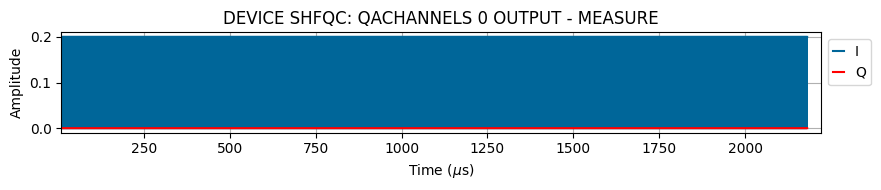

In [105]:
plot_simulation(compiled_opm, 10e-6, 2210e-6)

In [106]:
run_opm = session.run(compiled_opm)

[2025.08.19 22:20:53.193] INFO    Starting near-time execution...
[2025.08.19 22:20:53.440] INFO    Finished near-time execution.


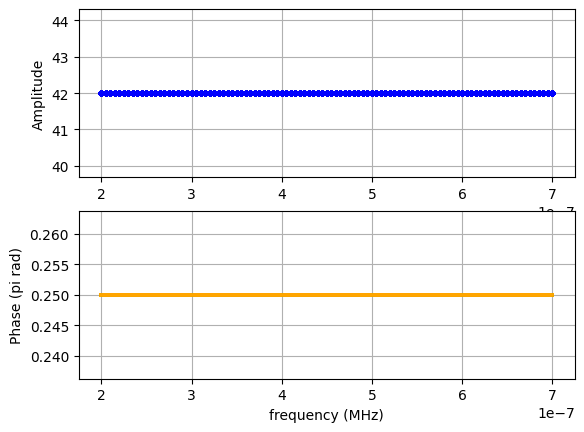

In [107]:
data_opm = run_opm.get_data("res_spec")
freq_opm = run_opm.get_axis("res_spec")[0]

fig, [ax1,ax2] = plt.subplots(2,1)
ax1.plot(freq_opm/1e6, np.real(data_opm), ".-r")
ax1.plot(freq_opm/1e6, np.imag(data_opm), ".-b")
ax2.plot(freq_opm/1e6, np.unwrap(np.angle(data_opm))/np.pi, "orange")
ax1.set_ylabel("Amplitude")
ax2.set_ylabel("Phase (pi rad)")
ax2.set_xlabel("frequency (MHz)")
ax1.grid()
ax2.grid()
plt.show()